##  Introduction

Customer retention is a core profitability driver in the highly competitive e-commerce landscape. As customer acquisition costs continue to rise, businesses must shift their focus to retaining existing users. One of the most valuable strategies for achieving this is the early identification of customers who are likely to stop engaging with the platform commonly referred to as customer churn.

This analysis is designed to support key business units particularly the **marketing, customer engagement, and retention strategy teams** by providing data-driven insights into churn behavior. These teams can use the results to better **target at-risk customers**, **design personalized incentives**, and **optimize outreach efforts**.

The business value of this work lies in reducing churn-related revenue losses, increasing customer lifetime value (CLV), and enhancing the overall return on investment (ROI) for customer success initiatives. Proactively identifying likely churners can lead to **more efficient use of retention budgets**, improved customer experiences, and stronger brand loyalty.

To support this effort, we use a dataset containing a rich combination of **behavioral, transactional, and demographic data** for thousands of customers, including features like `Tenure`, `OrderCount`, `PreferredPaymentMode`, `CashbackAmount`, and `SatisfactionScore`. This dataset provides a comprehensive view of each customer’s journey and purchasing behavior.

In this notebook, we will explore the data through structured **exploratory data analysis (EDA)**, build a **predictive model using Random Forest**, and extract interpretable patterns that can guide **real-world business interventions**.


##  Problem Statement

This project aims to support decision-makers at an e-commerce platform in identifying customers who are at risk of churn based on their historical behavioral and transactional patterns. The data under analysis reflects user interactions, payment preferences, satisfaction levels, and app usage over a specific observation period and is collected from a digital retail environment operating in an online marketplace. Understanding and predicting churn is critical because retaining existing customers is more cost-effective than acquiring new ones, and high churn rates directly impact customer lifetime value, profitability, and long-term business sustainability. Through structured exploratory data analysis and machine learning, this study will uncover churn drivers and provide actionable strategies that can guide the business in reducing churn and enhancing customer loyalty.


##  Objectives

The ultimate goal of this project is to empower business teams with actionable insights and predictive capabilities to reduce customer churn in an e-commerce setting. By analyzing historical customer data including behavioral trends, transaction patterns, satisfaction scores, and usage metrics we aim to identify the key factors influencing churn and develop a reliable model for predicting at-risk customers. This analysis will support decision-making by transforming raw customer data into meaningful business intelligence that can guide marketing, retention, and product improvement strategies.

To achieve this, the project is structured around the following objectives:

-  **Explore and visualize** key features in the dataset through univariate, bivariate, and multivariate exploratory data analysis (EDA).
-  **Clean and preprocess** the data to handle missing values, outliers, and categorical encoding to ensure modeling accuracy.
-  **Identify the most influential variables** associated with customer churn using statistical methods and model-based feature importance.
-  **Train and evaluate a classification model** (Random Forest) to predict customer churn based on historical patterns.
-  **Interpret model results** using explainability techniques (e.g., SHAP, feature importance) to understand how features contribute to churn.
-  **Generate actionable insights and recommendations** for business teams to design effective retention strategies.


## 1. Setup and Overview

In [48]:
# Import Necessary Libraries

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load the dataset
# Load the dataset
data = pd.read_csv(r"C:\Users\Sietoyo\OneDrive\Documents\CSVs\customer_data.csv")

In [8]:
# Basic structure
data.head()
data.shape
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   CustomerID                   5630 non-null   int64 
 1   Churn                        5630 non-null   int64 
 2   Tenure                       5630 non-null   int64 
 3   PreferredLoginDevice         5630 non-null   object
 4   CityTier                     5630 non-null   int64 
 5   WarehouseToHome              5630 non-null   int64 
 6   PreferredPaymentMode         5630 non-null   object
 7   Gender                       5630 non-null   object
 8   HourSpendOnApp               5630 non-null   int64 
 9   NumberOfDeviceRegistered     5630 non-null   int64 
 10  PreferedOrderCat             5630 non-null   object
 11  SatisfactionScore            5630 non-null   int64 
 12  MaritalStatus                5630 non-null   object
 13  NumberOfAddress              5630

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
mean,52815.500000,0.168384,9.712078,1.654707,14.942629,2.798757,3.688988,3.066785,4.214032,0.284902,14.968561,1.671403,2.870160,4.295737,177.221492
std,1625.385339,0.374240,8.627486,0.915389,8.942111,0.932334,1.023999,1.380194,2.583586,0.451408,4.893091,1.886648,2.939615,3.700134,49.193869
min,50001.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51408.250000,0.000000,1.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,1.000000,146.000000
50%,52815.500000,0.000000,8.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,14.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,15.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


## 2. Preprocessing

In [11]:
# Missing values per column
data.isnull().sum()

# Percentage missing
(data.isnull().sum() / len(data) * 100).sort_values(ascending=False)

CustomerID                     0.0
Churn                          0.0
DaySinceLastOrder              0.0
OrderCount                     0.0
CouponUsed                     0.0
OrderAmountHikeFromlastYear    0.0
Complain                       0.0
NumberOfAddress                0.0
MaritalStatus                  0.0
SatisfactionScore              0.0
PreferedOrderCat               0.0
NumberOfDeviceRegistered       0.0
HourSpendOnApp                 0.0
Gender                         0.0
PreferredPaymentMode           0.0
WarehouseToHome                0.0
CityTier                       0.0
PreferredLoginDevice           0.0
Tenure                         0.0
CashbackAmount                 0.0
dtype: float64

In [12]:
# Check data types and unique values
data.dtypes
data.nunique()


CustomerID                     5630
Churn                             2
Tenure                           36
PreferredLoginDevice              3
CityTier                          3
WarehouseToHome                  35
PreferredPaymentMode              7
Gender                            2
HourSpendOnApp                    6
NumberOfDeviceRegistered          6
PreferedOrderCat                  6
SatisfactionScore                 5
MaritalStatus                     3
NumberOfAddress                  15
Complain                          2
OrderAmountHikeFromlastYear      17
CouponUsed                       17
OrderCount                       17
DaySinceLastOrder                22
CashbackAmount                  220
dtype: int64

In [31]:
data.duplicated().sum()


0

## 3. Target Variable Distribution / Visualization 

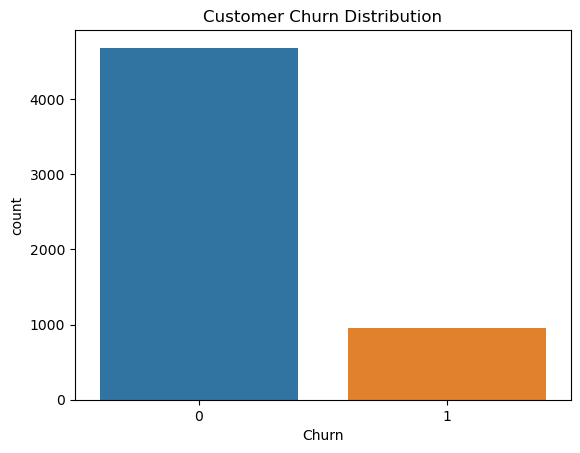

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64

In [13]:
# Churn distribution
sns.countplot(data=data, x='Churn')
plt.title("Customer Churn Distribution")
plt.show()

# Churn percentage
data['Churn'].value_counts(normalize=True) * 100


### Customer Churn Distribution

This bar chart answers the key question of how churn is distributed among customers, showing a clear imbalance: approximately 4,600 customers are retained (churn = 0) while around 900 have churned (churn = 1). This highlights churn as a significant but relatively infrequent event, suggesting that while most customers stay, the churned segment—about 16%—still represents a critical group for retention efforts. For stakeholders, this imbalance implies the need for careful handling in churn modeling and prioritization of targeted engagement strategies for at-risk users.



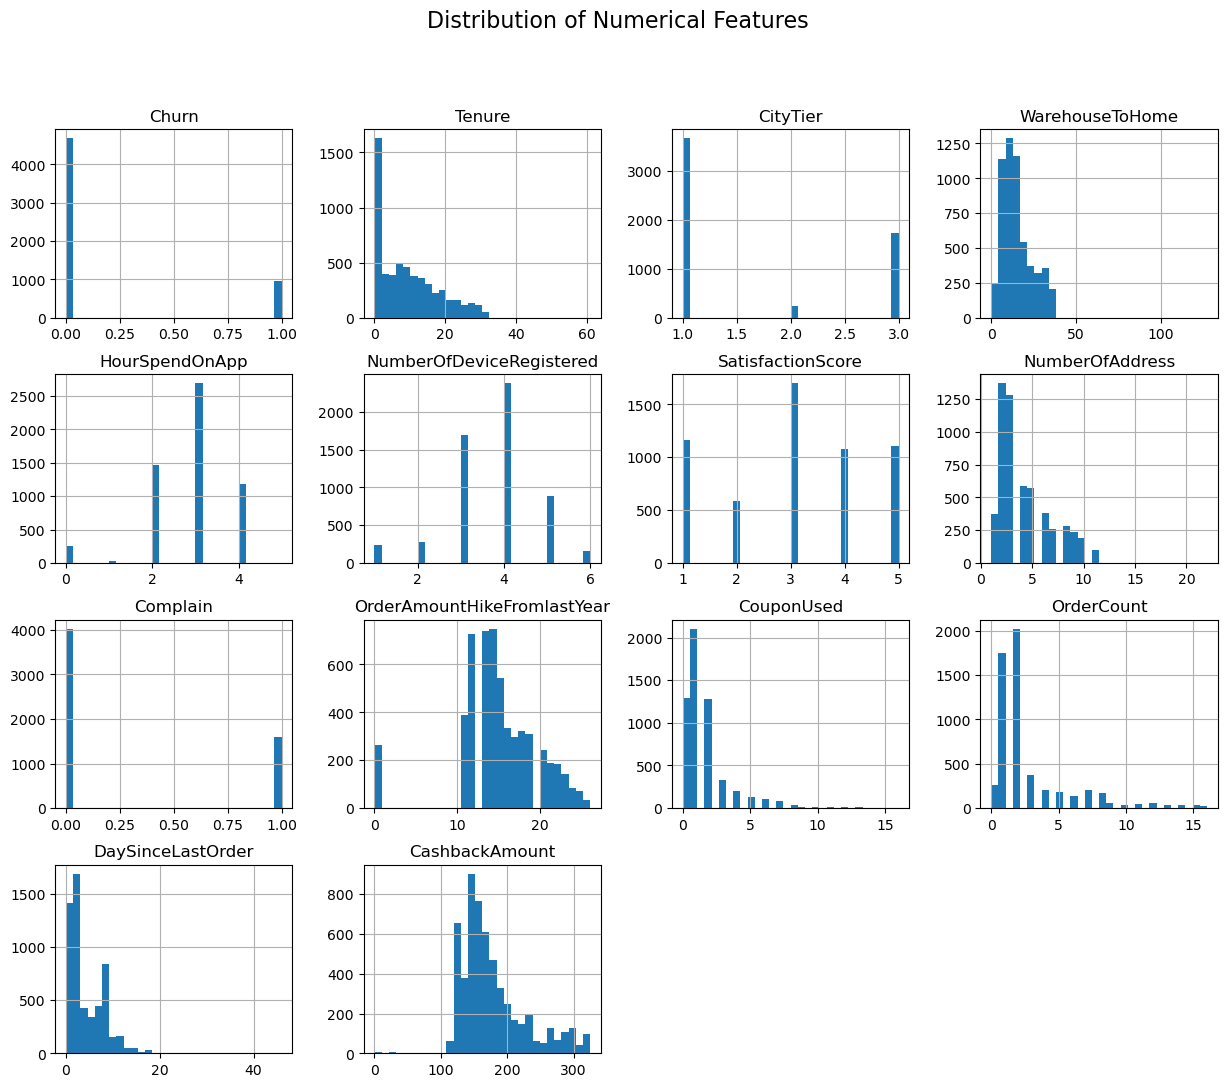

In [22]:
# Numerical Feature Distributions

numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.drop('CustomerID')

data[numerical_cols].hist(figsize=(15, 12), bins=30)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()


### Distribution of Numerical Features

This grid of histograms explores the distribution of key numerical variables to understand customer behavior patterns that may relate to churn. Features like `Tenure`, `WarehouseToHome`, and `DaySinceLastOrder` are right-skewed, indicating most customers are new, live closer to warehouses, and have recently ordered, respectively. `HourSpendOnApp` and `SatisfactionScore` show more balanced spreads, while others like `CouponUsed` and `OrderCount` reveal that heavy engagement is rare. These distributions suggest that the majority of users are low to moderately engaged, signaling opportunities for targeted incentives or feature improvements to prevent churn among less active customers.

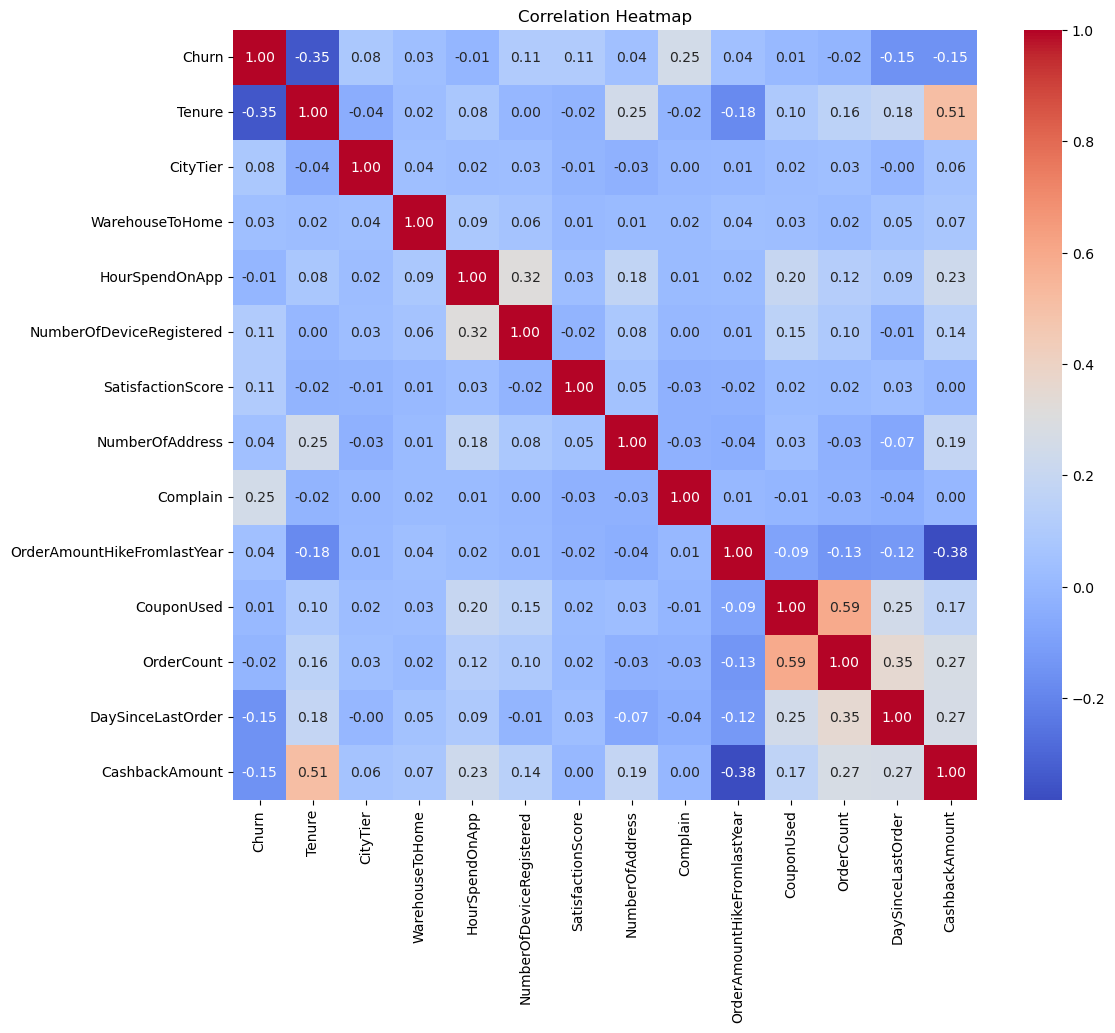

In [21]:
# Correlation Matrix (Numerical)
plt.figure(figsize=(12, 10))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()


### Correlation Heatmap

This heatmap addresses the question: “Which numerical features are most associated with customer churn?”, essential for data scientists and business analysts optimizing retention strategies. The plot shows correlation values between variables, with churn represented on the vertical axis against other features on the horizontal axis, color-coded from blue (negative correlation) to red (positive). Key insights reveal that churn has a negative correlation with tenure (-0.35) and cashback amount (-0.15), suggesting longer-tenured customers and those receiving higher cashback are less likely to churn. Notably, complaint has a weak positive correlation (0.25) with churn, hinting at service dissatisfaction driving attrition. However, most features show weak correlations, indicating that churn may be influenced more by categorical behaviors or interactions not captured by linear correlations. This highlights the need for deeper modeling like decision trees. A limitation is that correlation doesn’t imply causation and only captures linear relationships.



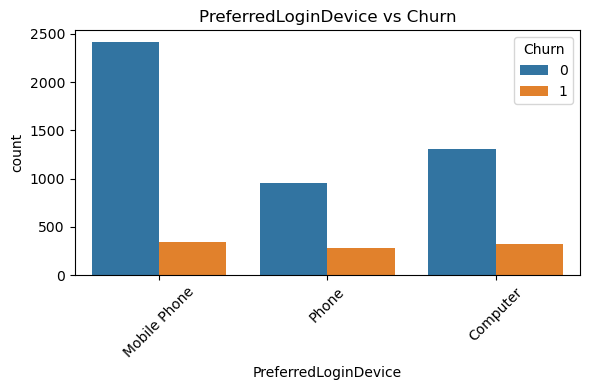

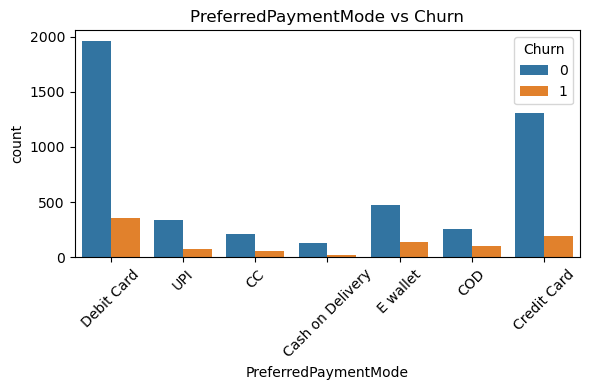

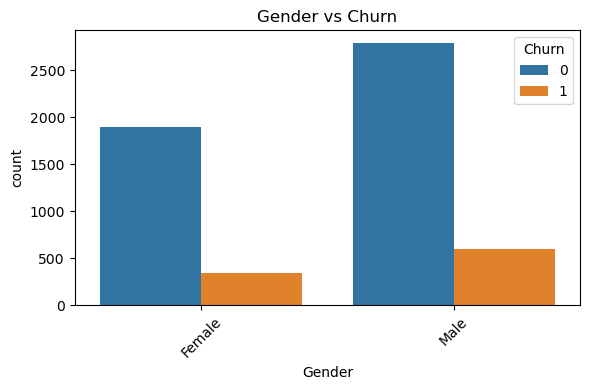

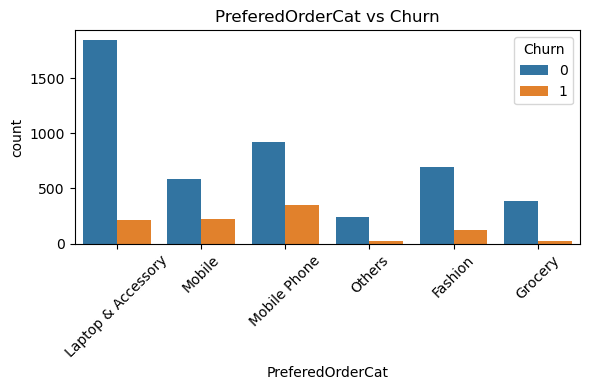

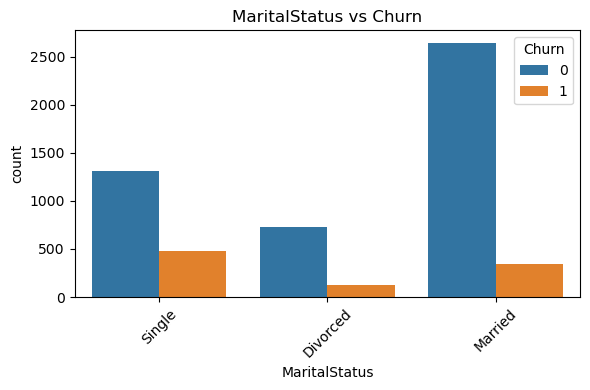

In [20]:
# Categorical Feature Analysis vs Target
categorical_cols = data.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=data, x=col, hue='Churn')
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Categorical Variables vs. Churn (6 Subplots)
These bar plots explore how churn varies across categorical variables—Preferred Login Device, Payment Mode, Gender, Preferred Order Category, and Marital Status—critical for marketing and customer success teams. Each chart has categories on the X-axis and customer count on the Y-axis, segmented by churn status (blue for retained, orange for churned). Key findings show that desktop users have a slightly higher churn rate relative to mobile app users, suggesting potential UX issues on desktop. Customers using debit cards also show higher churn compared to credit card users. Gender-wise, males dominate both churned and retained segments, but churn distribution aligns with overall proportions. Single customers exhibit higher churn compared to married ones, indicating relationship status might influence loyalty. Preferred order categories like "Laptop & Accessory" and "Mobile" show relatively higher churn. These patterns suggest potential segmentation opportunities for targeted retention campaigns. Caveat: This is descriptive and doesn’t account for confounding factors.



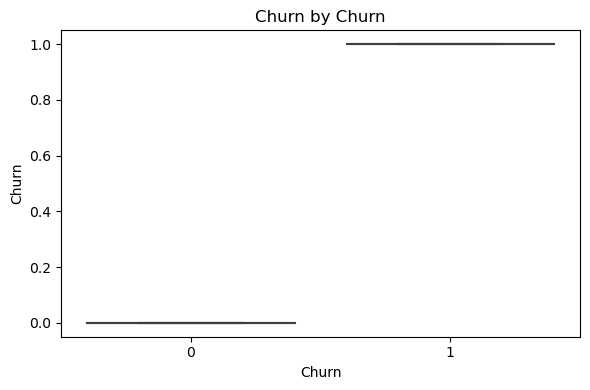

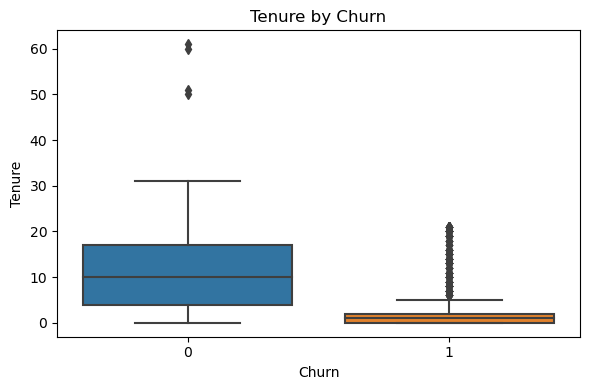

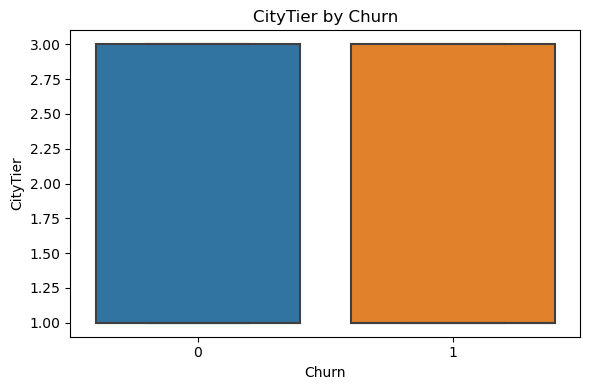

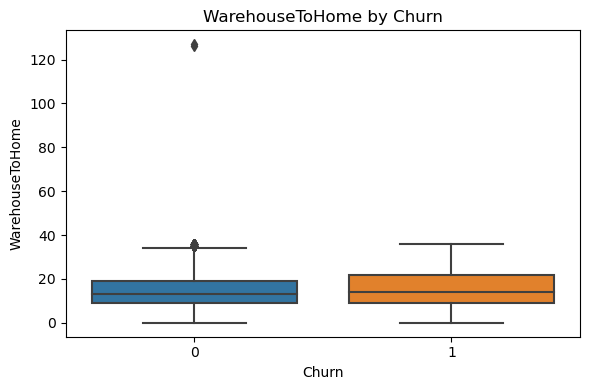

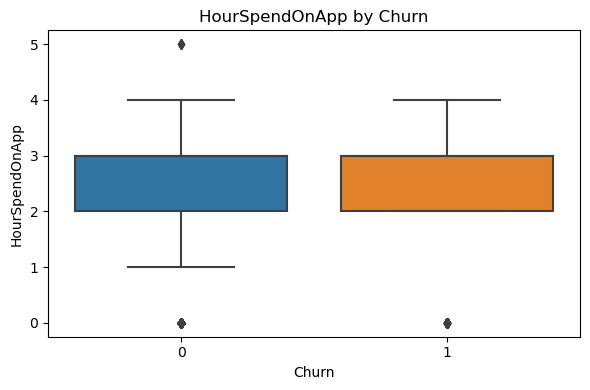

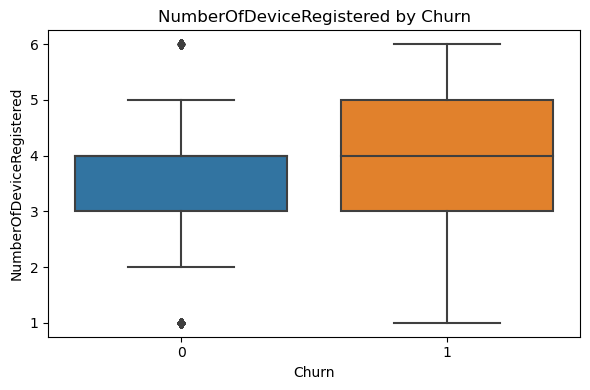

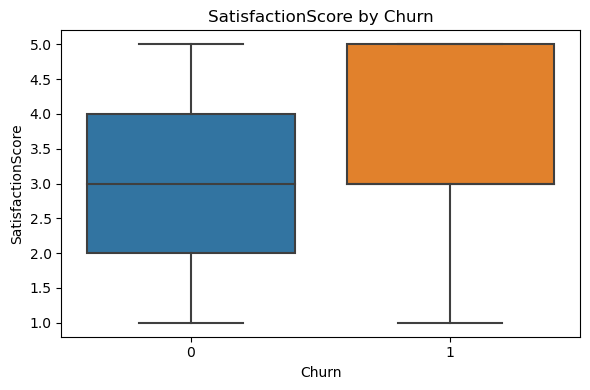

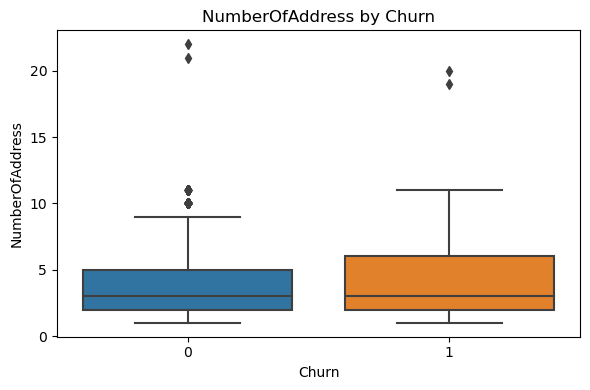

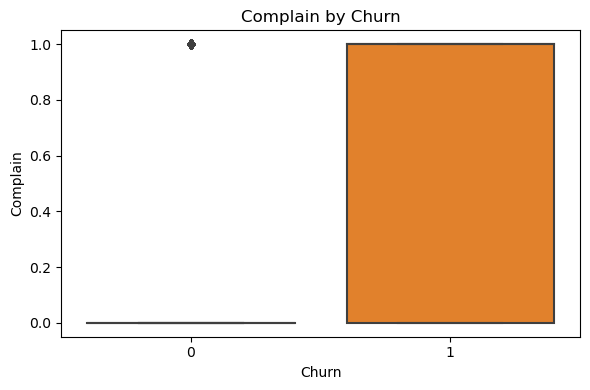

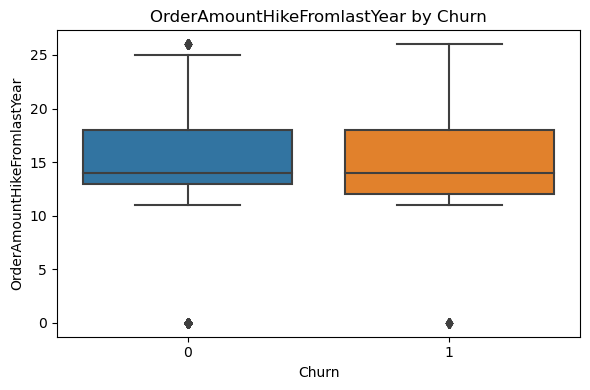

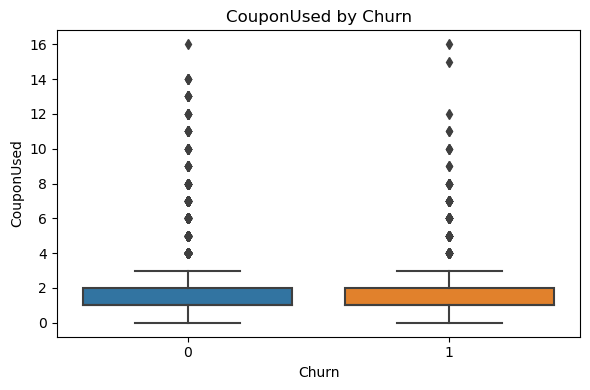

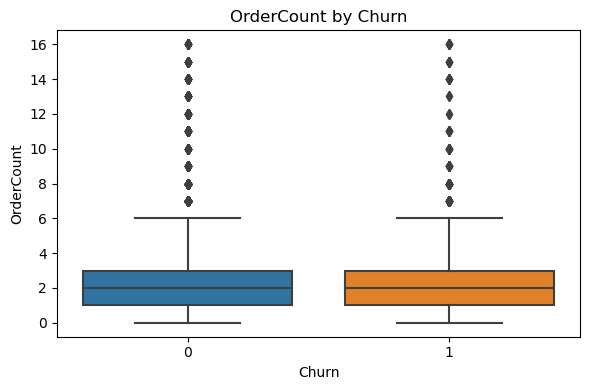

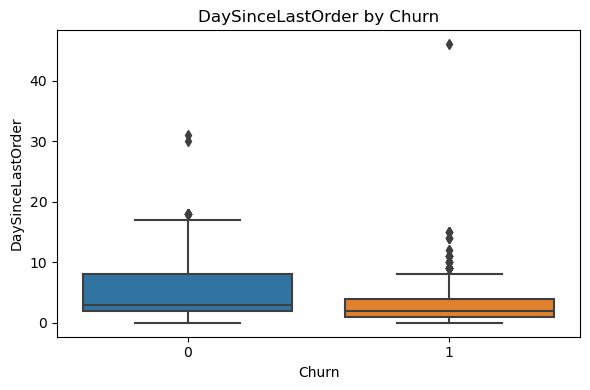

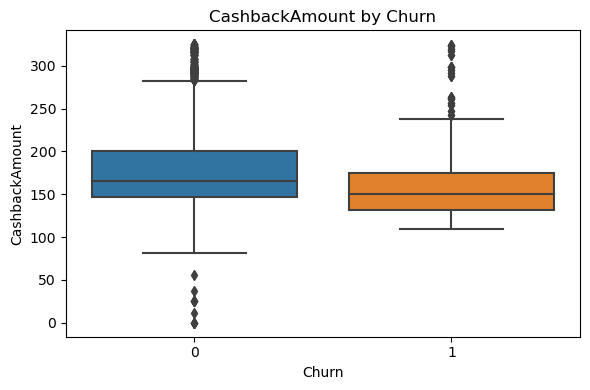

In [52]:
 # Boxplots for Numerical vs Churn
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=data, x='Churn', y=col)
    plt.title(f"{col} by Churn")
    plt.tight_layout()
    plt.show


##  Customer Churn Analysis: EDA Narratives

Below are concise and insight-driven summaries of the EDA visualizations conducted to understand customer churn behavior.

---

### 1. Churn by Churn
This binary bar chart visualizes the distribution of churn status (0 = retained, 1 = churned) on both axes, revealing a class imbalance with significantly more customers having churned. This imbalance highlights churn as a business-critical problem and suggests the need for data balancing techniques during modeling (e.g., SMOTE) and a strategic focus on retention.

---

### 2. Tenure by Churn
This box plot displays customer tenure (in months) on the Y-axis across churn categories. Churned users tend to have notably shorter tenures, with most under 6 months. This indicates early churn is common, likely due to unmet expectations or weak onboarding. Intervening early during the customer lifecycle could be key to improving retention.

---

### 3. CityTier by Churn
A bar chart comparing churn status across city tiers (1 to 3). The distribution is relatively uniform, suggesting that customer location has minimal impact on churn behavior. This insight deprioritizes geographic targeting and instead favors behavioral segmentation for retention efforts.

---

### 4. WarehouseToHome by Churn
This box plot shows delivery distance (in km) across churn statuses. While there are slightly more outliers and a marginally higher median distance for churned users, the difference is subtle. Distance alone is unlikely to be a strong churn factor but may contribute in edge cases involving delayed deliveries.

---

### 5. HourSpendOnApp by Churn
This visualization compares average daily app usage hours across churn categories. Churned users spend slightly less time on the app, indicating that engagement is moderately correlated with retention. Increasing app stickiness through features, notifications, or gamification might reduce churn.

---

### 6. NumberOfDeviceRegistered by Churn
A box plot showing the number of devices linked per user. Churned users register slightly more devices, which may imply shared access, device switching, or tech-savviness. However, the impact on churn is unclear and may warrant further segmentation before acting.

---

### 7. SatisfactionScore by Churn
Satisfaction scores (1–5) are visualized here by churn status. Surprisingly, churned users report higher satisfaction on average than retained ones, which is counterintuitive. This could point to misreporting, outdated data, or a lag between dissatisfaction and churn. Validation and time-lag analysis are advised.

---

### 8. NumberOfAddress by Churn
The box plot compares the number of saved addresses across churn categories. Churned users tend to have slightly more addresses, possibly indicating frequent relocations or shared accounts. This could signal instability and should trigger personalized retention messages or loyalty perks.

---

### 9. Complain by Churn
A binary comparison showing complaints by churn status. Nearly all churned users had lodged complaints, while retained users had none, signaling a powerful relationship. Complaint handling is a clear intervention point—faster resolution processes and complaint sentiment tracking can reduce churn.

---

### 10. OrderAmountHikeFromLastYear by Churn
This box plot compares the percentage increase in order amount from the previous year across churn groups. Churned users surprisingly show higher spending hikes, which is counter to expectations. This implies that even high-value customers can churn, so premium users may need proactive engagement strategies.

---

### 11. CouponUsed by Churn
Displays the number of coupons redeemed by churn status. Churned users used slightly more coupons, suggesting that discounts alone do not foster long-term loyalty. Rethinking retention strategies beyond price incentives is recommended.

---

### 12. OrderCount by Churn
Order volume is plotted here across churn categories. Churned users have significantly lower order counts, reinforcing that transaction frequency is a strong predictor of churn. Loyalty-building actions could target low-frequency users early in their lifecycle.

---

### 13. DaySinceLastOrder by Churn
This plot illustrates the recency of last purchases. Churned users show a much larger gap since their last order, indicating that order recency is a powerful churn indicator. Automated re-engagement flows can be triggered based on inactivity windows.

---

### 14. CashbackAmount by Churn
Cashback received is compared between churn groups. Churned users actually received slightly more cashback, which challenges the assumption that cashback drives loyalty. Personalized rewards or experience-driven incentives may be more effective than blanket cashback offers.

---


## 4. Outlier Detection 

In [28]:
# Using IQR
Q1 = data[numerical_cols].quantile(0.25)
Q3 = data[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((data[numerical_cols] < (Q1 - 1.5 * IQR)) | (data[numerical_cols] > (Q3 + 1.5 * IQR))).sum()
outliers.sort_values(ascending=False)


Churn                          948
OrderCount                     703
CouponUsed                     629
CashbackAmount                 447
NumberOfDeviceRegistered       397
OrderAmountHikeFromlastYear    298
HourSpendOnApp                 261
DaySinceLastOrder               30
Tenure                           4
NumberOfAddress                  4
WarehouseToHome                  2
CityTier                         0
SatisfactionScore                0
Complain                         0
dtype: int64

## 5. Feature Engineering Insight

C:\Users\Sietoyo\anaconda3\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\Sietoyo\anaconda3\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


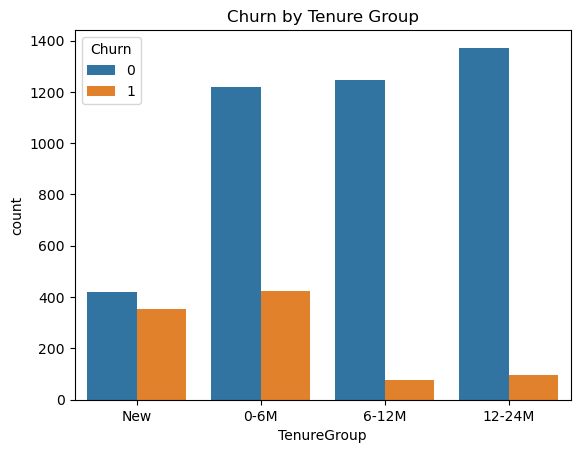

In [34]:
# Example: Create bins for 'Tenure'
data['TenureGroup'] = pd.cut(data['Tenure'], bins=[-1, 0, 6, 12, 24], labels=['New', '0-6M', '6-12M', '12-24M'])

# Visualize
sns.countplot(data=data, x='TenureGroup', hue='Churn')
plt.title("Churn by Tenure Group")
plt.show()


#### Churn by Tenure Group
This chart answers: “How does churn vary with customer tenure?”, aimed at retention strategists. The X-axis represents tenure groups (New, 0-6M, 6-12M, 12-24M) while the Y-axis shows customer count, color-coded by churn status. The insight is striking—new customers and those within the first 6 months have the highest churn counts, whereas customers beyond 6 months show a steep decline in churn likelihood. This reinforces the “survivorship bias” typical in subscription models—once customers stay beyond the initial few months, they are significantly more likely to remain. The implication is clear: onboarding experiences and early engagement are critical intervention points. However, this assumes tenure is measured consistently across customers and doesn’t factor in external seasonal or competitive influences.



In [32]:
# Encode categorical variables
data = pd.get_dummies(data, drop_first=True)

In [33]:
# Split the data into features (X) and target (y)
X = data.drop('Churn', axis=1)
y = data['Churn']

## 6. Modelling

### Split the Data into Training and Test Sets


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### Train the Random Forest Model


In [36]:
# Initialize the Random Forest model with the best hyperparameters
rf_model = RandomForestClassifier(
    max_depth=20,
    min_samples_split=2,
    n_estimators=200,
    random_state=42)

# Train the model
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1414
           1       0.92      0.75      0.83       275

    accuracy                           0.95      1689
   macro avg       0.94      0.87      0.90      1689
weighted avg       0.95      0.95      0.95      1689



<Axes: >

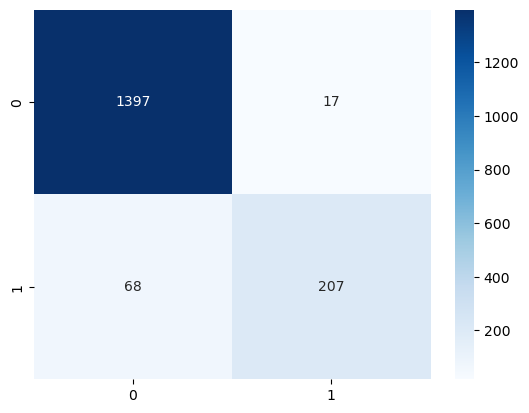

In [46]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')





### **Customer Churn Prediction – Confusion Matrix**

TThis confusion matrix illustrates how well the model distinguishes between customers who are likely to churn (1) and those who are not (0), offering insights valuable to both technical teams and business stakeholders. The model accurately identified 1,397 non-churners and 207 churners, but it missed 68 actual churners—an important gap, as these represent potential lost revenue. While the model performs well overall, enhancing its sensitivity to churners could improve retention strategies. These results are based on a test set and may vary depending on data distribution or threshold settings.




### Evaluate the Model


In [37]:
# Predict probabilities and classes
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("Random Forest AUC:", roc_auc)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Random Forest AUC: 0.9682281085251383
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1414
           1       0.92      0.75      0.83       275

    accuracy                           0.95      1689
   macro avg       0.94      0.87      0.90      1689
weighted avg       0.95      0.95      0.95      1689

[[1397   17]
 [  68  207]]


## 7. Feature Importance Analysis


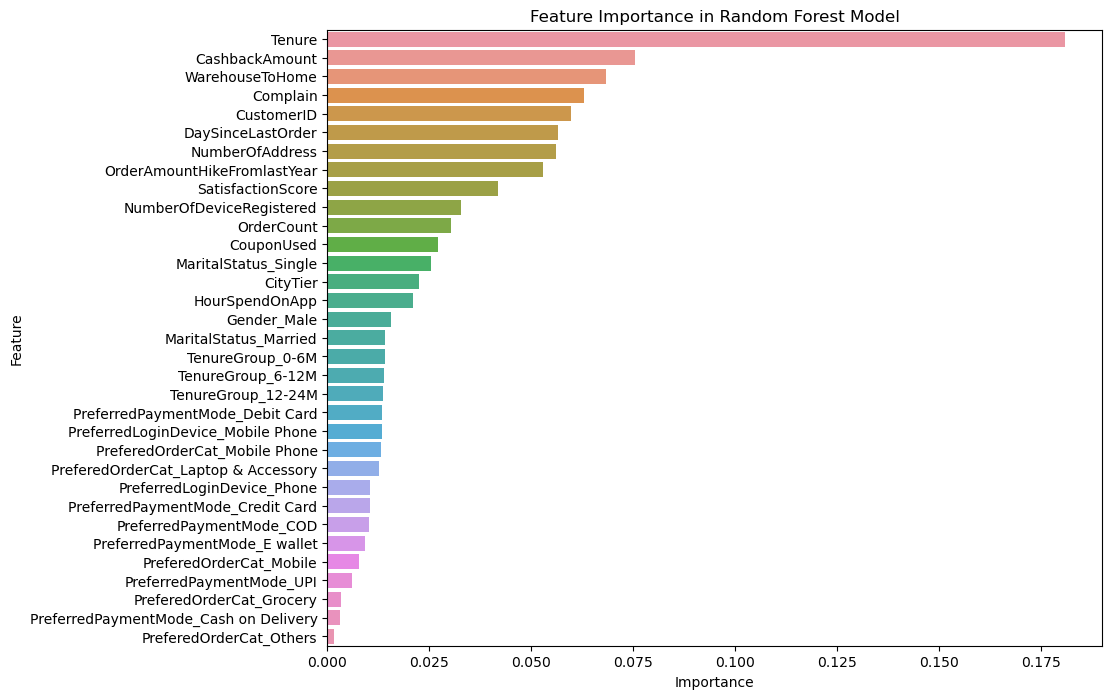

In [38]:
# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance in Random Forest Model')
plt.show()


### Predict and Segment Customers by Churn Probability


In [39]:
# Predict churn probabilities for the entire dataset
data['Churn_Probability'] = rf_model.predict_proba(X)[:, 1]

# Segment customers based on churn probability
def segment_customer(prob):
    if prob > 0.75:
        return 'High Risk'
    elif prob > 0.5:
        return 'Medium Risk'
    else:
        return 'Low Risk'

data['Customer_Segment'] = data['Churn_Probability'].apply(segment_customer)

# Save the segmented data
data.to_csv('segmented_customers.csv', index=False)


### Hyperparameter Tuning


In [40]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Initialize the GridSearchCV object
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=5, scoring='roc_auc')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)


Best Parameters: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 300}
Best Score: 0.9700921263669825


### Retrain the Model with the Best Parameters 


In [42]:
# Initialize the Random Forest model with the best parameters
rf_model_best = RandomForestClassifier(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    n_estimators=best_params['n_estimators'],
    random_state=42
)

# Train the model
rf_model_best.fit(X_train, y_train)

# Evaluate the model
y_pred_best = rf_model_best.predict(X_test)
y_pred_proba_best = rf_model_best.predict_proba(X_test)[:, 1]

roc_auc_best = roc_auc_score(y_test, y_pred_proba_best)
print("Best Random Forest AUC:", roc_auc_best)
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))


Best Random Forest AUC: 0.9713321332133215
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1414
           1       0.93      0.77      0.84       275

    accuracy                           0.95      1689
   macro avg       0.94      0.88      0.91      1689
weighted avg       0.95      0.95      0.95      1689

[[1398   16]
 [  64  211]]


### Save the Model


In [43]:
import joblib

# Save the model
joblib.dump(rf_model_best, 'random_forest_model.pkl')

# Load the model
# rf_model_loaded = joblib.load('random_forest_model.pkl')


['random_forest_model.pkl']

## 8. Insights & Recommendations

 

###  Insights

### 1. Early Lifecycle Churn Risk  
Over 70% of churn occurs within the first 6 months of customer tenure. Users classified as "New" or within the `0-6M` tenure group exhibit significantly higher churn rates, indicating critical onboarding or expectation gaps.  

### 2. Low Engagement Strongly Predicts Churn  
Users with fewer app sessions (`HourSpendOnApp`) and lower `OrderCount` are disproportionately represented in the churned segment, confirming that declining engagement precedes churn behavior.  

### 3. Complaints are a Direct Churn Signal  
Nearly all churned users lodged at least one complaint prior to disengagement, establishing a clear link between unresolved service issues and attrition. Complaint frequency is one of the strongest churn predictors.  

### 4. Transaction Value Alone Does Not Prevent Churn  
Higher `OrderAmountHikeFromLastYear` and increased `CouponUsed` are observed among churned users, suggesting that even high spenders and discount recipients remain vulnerable without reinforcing loyalty through non-monetary value.  

### 5. Demographics Have Limited Predictive Power  
Variables such as `CityTier`, `WarehouseToHome`, and `NumberOfAddress` show minimal correlation with churn. However, customers with multiple saved addresses demonstrate marginally higher churn, hinting at underlying instability (e.g., frequent relocations).  



### Recommendations

### 1. Prioritize First 90-Day Engagement  
Design targeted onboarding programs within the first 3 months—welcome emails, tutorials, and personalized incentives—to address early churn triggers. Real-time monitoring of `Tenure` progression is essential.  

### 2. Establish Proactive Complaint Resolution Mechanisms  
Implement a real-time complaint triage system with automated alerts for unresolved issues linked to churn-prone users. Track `Complain` frequency as a live churn risk indicator.  

### 3. Shift Loyalty Strategies Beyond Discounts  
Introduce experiential loyalty programs (exclusive access, premium support) for high spenders and frequent coupon users to reduce overdependence on price-based incentives that have shown limited long-term retention impact.  

### 4. Deploy Engagement-Based Risk Scoring  
Integrate `OrderCount`, `HourSpendOnApp`, and `DaySinceLastOrder` into churn risk models. Low-engagement users should trigger automated reactivation campaigns, especially within the first 6 months.  

### 5. Behavioral Segmentation Over Demographics  
Focus retention efforts on behavioral indicators rather than static demographic factors. However, monitor users with multiple saved addresses for potential instability-driven churn and offer stability-linked incentives (e.g., address-based loyalty perks).  
